In [1]:
import os
import sys 
from pyprojroot import here
sys.path.insert(0, str(here()))
from os.path import exists

import geopandas as gpd
from laos_gggi.data_functions import load_emdat_data, load_shapefile, load_rivers_data
from laos_gggi.data_functions.disaster_point_data import (load_disaster_point_data, 
                    load_synthetic_non_disaster_points, load_grid_point_data, load_non_disaster_grid)

from laos_gggi.plotting import configure_plot_style
from laos_gggi.statistics import get_distance_to_rivers, prediction_to_gpd_df , set_plotting_data, add_data, add_country_effect
from laos_gggi.data_functions.combine_data import load_all_data
from pymc.model.transform.optimization import freeze_dims_and_data

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import xarray as xr
import arviz as az
import scipy
import nutpie
import pathlib

import pymc as pm
import pytensor.tensor as pt
from laos_gggi.sample import sample_or_load


from laos_gggi.transformers import Standardize
from laos_gggi.data_functions.world_bank_data_loader import load_wb_data

configure_plot_style()

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from laos_gggi.data_functions import load_ocean_heat_data
from laos_gggi.const_vars import OCEAN_HEAT_URL

In [4]:
df_ocean = pd.read_csv(OCEAN_HEAT_URL, header=0, names=["Date", "Temp"])
df_ocean.Date = pd.to_datetime(df_ocean.Date, format="%Y-%m")
df_ocean.set_index("Date", inplace=True)
df_ocean = df_ocean.resample("YE").mean()
df_ocean.reset_index(inplace=True)
df_ocean["Date"] = df_ocean["Date"] - pd.offsets.YearBegin()
df_ocean.set_index("Date", inplace=True)

# Load and prepare data

In [5]:
world = load_shapefile('world')
# rivers = load_rivers_data()
laos = world.query('ISO_A3 == "LAO"')

# Select SEA shape
region_list = [
    'IDN',  # Indonesia
]

region_map = world.query('ISO_A3 in @region_list')

In [6]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
region_point_grid = load_grid_point_data(region='custom', grid_size=400, 
                            force_reload = False, 
                            iso_list=region_list,
                           file_reg_name="IDN" ).rename(columns = {"lon": "long"})

region_point_grid_training = load_grid_point_data(region='custom', grid_size=200, 
                            force_reload = False, 
                            iso_list=region_list,
                            file_reg_name="IDN" ).rename(columns = {"lon": "long"})

Loading data found at C:\Users\camil\Documents\Servicios\OCDE-GGI\laos-climate-change\data\shapefiles\IDN_points_400.shp\IDN_points_400.shp.shp
Loading data found at C:\Users\camil\Documents\Servicios\OCDE-GGI\laos-climate-change\data\shapefiles\IDN_points_200.shp\IDN_points_200.shp.shp


In [8]:
all_data = load_all_data()
panel_data  = all_data["df_panel"][['population_density', 'gdp_per_cap', 'Population', 'precip', "real_gdp"]]
co2 = all_data["df_time_series"]["co2"]

In [9]:
# Load disasters and non-disasters
disasters = load_disaster_point_data()
# not_disasters = load_synthetic_non_disaster_points(by='country', multiplier=3)

not_disasters = not_disasters = load_synthetic_non_disaster_points(countries= region_list, 
                                                   list_name= 'IDN',
                                                   by='country',
                                                   multiplier=15, 
                                                   force_generate = False)


# Merge data frames
merged_df = pd.concat([not_disasters.assign(is_disaster = 0), 
                       disasters.reset_index().assign(is_disaster=1)], 
                      ignore_index= True)

# Adjust date format
merged_df["Start_Year"] = pd.to_datetime(merged_df["Start_Year"])

Loading data found at C:\Users\camil\Documents\Servicios\OCDE-GGI\laos-climate-change\data\synthetic_non_disasters_country_times_15_IDN_.csv


In [10]:
from statsmodels.tsa.seasonal import STL

precipitation = all_data["gpcc"]
precip_deviation = precipitation.groupby('ISO').transform(lambda x: x - x.iloc[:30].mean()).rename(columns={'precip':'precip_deviation'})

df_clim = all_data["df_time_series"][["co2", "Temp", "precip"]].iloc[1:-1].dropna(subset=['Temp'])
trend =  STL(pd.DataFrame(df_clim["Temp"].dropna()), period=3).fit().trend
dev_from_trend_ocean_temp = (df_clim['Temp'] - trend).to_frame(name='dev_ocean_temp')

In [11]:
from functools import reduce
df = reduce(lambda l, r: pd.merge(l, r, left_on=['ISO', 'Start_Year'], right_index=True, how='left'), [merged_df, panel_data, precip_deviation])
df = reduce(lambda l, r: pd.merge(l, r , left_on=['Start_Year'], right_index=True, how='left'), [df, co2, dev_from_trend_ocean_temp])

In [12]:
#Creating log variables
log_list = ["distance_to_river", "distance_to_coastline", "Total_Affected", "Total_Damage_Adjusted", "population_density",
            "gdp_per_cap"]
for y in log_list:
    df[f"log_{y}"] = np.log(df[y])



C:\Users\camil\miniforge3\envs\laos-climate-change\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [13]:
#Delimiting data set
columns_to_use = ['ISO', 'Start_Year', "is_disaster", 'distance_to_river', 'distance_to_coastline',
               "Population", "co2", "precip_deviation", "dev_ocean_temp", "lat", "long" , "geometry", "real_gdp"]

features = ['log_distance_to_river', 'log_distance_to_coastline',
             "Population", "co2", "precip_deviation", "dev_ocean_temp", 'log_population_density',
             'log_gdp_per_cap', ]

model_df = df[ list( set( columns_to_use).union(set(features)) )]


In [14]:
# Define list of features standardized
features_stand = []
for feature in features:
    features_stand.append(feature + "__standardized" )

time_varying_features = ['Population','co2','precip_deviation','dev_ocean_temp','log_population_density','log_gdp_per_cap',]
time_varying_features_stand = []

for feature in time_varying_features:
    time_varying_features_stand.append(feature + "__standardized")

### Create region and country data sets

In [15]:
#Create the geodata set for sea disasters
region_disasters = model_df.query('ISO in @region_list & is_disaster == 1')

region_disasters_geo = gpd.GeoDataFrame(
                region_disasters,
    geometry=gpd.points_from_xy(region_disasters["long"], region_disasters["lat"]), crs="EPSG:4326"
            )

# Create the geodata set for countries disasters
country_disasters = {}
country_disasters_geo = {}

for country in region_list:
    country_disasters[country] = model_df.query('ISO == @country & is_disaster == 1')
    country_disasters_geo[country] = gpd.GeoDataFrame(
                    country_disasters[country],
        geometry=gpd.points_from_xy(country_disasters[country]["long"], country_disasters[country]["lat"]), crs="EPSG:4326"
                )

In [16]:
# Define dfs
region_df = model_df.query('ISO in @region_list')

#Tranform dfs to geopandas df
region_df = gpd.GeoDataFrame(region_df,  geometry=gpd.points_from_xy(region_df["long"],
                                region_df["lat"]),crs="EPSG:4326")


In [17]:
# Merge geospatial data with time varying data

region_2020_data =  region_df.query('Start_Year == "2020-01-01"').iloc[[0]][time_varying_features + ["ISO", "real_gdp"]]
region_2016_data =  region_df.query('Start_Year == "2016-01-01"').iloc[[0]][time_varying_features + ["ISO", "real_gdp"]]


C:\Users\camil\AppData\Local\Temp\ipykernel_63416\1758986343.py:3: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  region_2020_data =  region_df.query('Start_Year == "2020-01-01"').iloc[[0]][time_varying_features + ["ISO", "real_gdp"]]
C:\Users\camil\AppData\Local\Temp\ipykernel_63416\1758986343.py:4: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  region_2016_data =  region_df.query('Start_Year == "2016-01-01"').iloc[[0]][time_varying_features + ["ISO", "real_gdp"]]


In [18]:
# Merge points with world ISO
region_point_grid_extended = {}
region_point_grid_extended_df = gpd.sjoin(region_point_grid, region_map, how="left", )
region_point_grid_extended_df = region_point_grid_extended_df.rename(columns = {"lon": "long"})


region_point_grid_extended["2020"] = pd.merge(region_point_grid_extended_df, region_2020_data, how = "left", left_on= "ISO_A3", right_on="ISO" ) 
region_point_grid_extended["2016"] = pd.merge(region_point_grid_extended_df, region_2016_data, how = "left", left_on= "ISO_A3", right_on="ISO" ) 

In [19]:
# country_point_grid = {}

# for country in region_list:
#     country_point_grid[country]['ISO'] = 

# # Creating the laos_point_grid_extended
# laos_point_grid["ISO"] = "LAO"
# laos_point_grid_extended = {}
# laos_point_grid_extended_df = gpd.sjoin(laos_point_grid, laos_map, how="left", )
# laos_point_grid_extended_df = laos_point_grid_extended_df.rename(columns = {"lon": "long"})
# laos_point_grid_extended["2020"] = pd.merge(laos_point_grid_extended_df, country_2020_data_df, how = "left", left_on= "ISO", right_on="ISO" ) 
# laos_point_grid_extended["2015"] = pd.merge(laos_point_grid_extended_df, country_2015_data_df, how = "left", left_on= "ISO", right_on="ISO" ) 


In [20]:
# drop NaNs

region_df = region_df.dropna()

In [21]:
# Standardize SEA data
transformer_stand_ =  Standardize().fit(region_df)
region_df_stand = transformer_stand_.transform(region_df)
# lao_df_stand = transformer_stand_.transform(lao_df)

# other dfs
region_point_grid_extended["2020"] = transformer_stand_.transform(region_point_grid_extended["2020"]) 
region_point_grid_extended["2016"] = transformer_stand_.transform(region_point_grid_extended["2016"]) 

# laos_point_grid_extended["2020"] = transformer_stand_.transform(laos_point_grid_extended["2020"]) 
# laos_point_grid_extended["2016"] = transformer_stand_.transform(laos_point_grid_extended["2016"])

In [22]:
# define terms to square and dfs
df_list =  [region_point_grid_extended["2020"], region_point_grid_extended["2016"], 
            # laos_point_grid_extended["2020"],
            # laos_point_grid_extended["2016"],
            region_df_stand, 
            # lao_df_stand
           ]

terms_to_square = ["log_gdp_per_cap__standardized", "log_population_density__standardized", 
                  # "log_distance_to_river__standardized", "log_distance_to_coastline__standardized"
                  ]

terms_to_square_squared = [x + "__squared" for x in terms_to_square]

# Add the sqaured versions of terms
for df_ in df_list:
    for x, y in zip(terms_to_square, terms_to_square_squared):
        df_[y] = df_[x] ** 2


# Adjust features_stand and  time_varying_features_stand
features_stand =  features_stand 
time_varying_features_stand = time_varying_features_stand 
# + terms_to_square_squared

In [23]:
# grid cols
grid_cols = ['ISO_A3', 'long', 'lat', 'log_distance_to_river','log_distance_to_coastline', 
 'geometry', ]

In [24]:
# Save files
region_point_grid_extended["2020"].to_csv(here("data/idn_point_grid.csv"))
# laos_point_grid_extended["2020"].to_csv(here("data/laos_point_grid.csv"))
region_df.to_csv(here("data/idn_df.csv"))
# lao_df.to_csv(here("data/lao.csv"))
region_df_stand.to_csv(here("data/idn_region_df_stand.csv"))
# lao_df_stand.to_csv(here("data/lao_df_stand.csv"))  

### ASEAN maps

[]

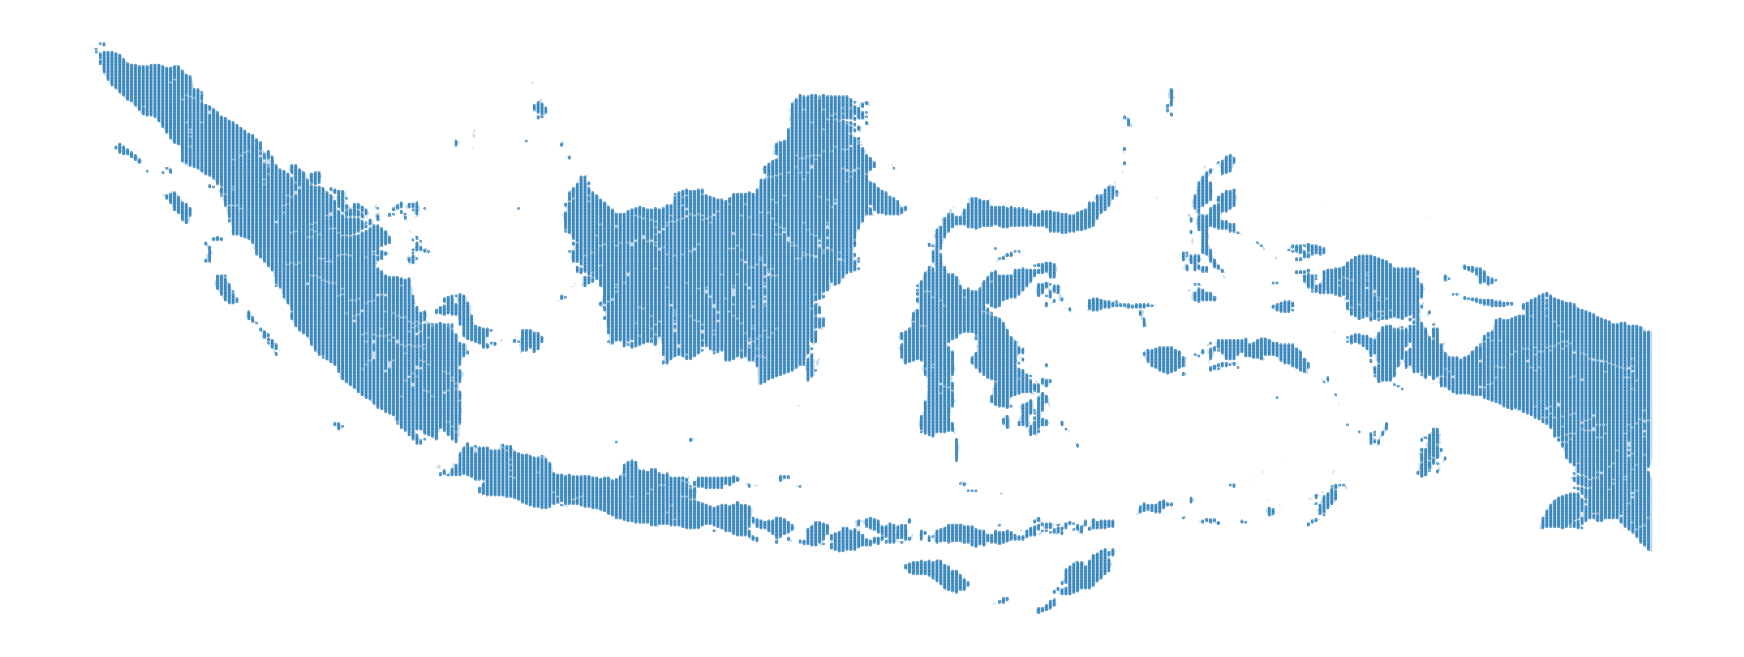

In [25]:
fig, ax = plt.subplots(figsize=(12, 6), dpi=144)
world.query('ISO_A3 in @region_list ').plot(facecolor='tab:blue', alpha=0.25, ax=ax)
region_point_grid_extended_df.query('distance_to_river > 1000').plot('is_island', ax=ax , markersize=0.1)
ax.set_xticks([])
ax.set_yticks([])

In [26]:
# import numpy as np
# import matplotlib.pyplot as plt
# from adjustText import adjust_text

# fig, ax = plt.subplots(figsize=(14, 9), dpi=144)

# # Plot the map and disaster locations
# world.query('ISO_A3 == "LAO"').plot(facecolor='tab:blue', alpha=0.25, ax=ax)
# world.query('ISO_A3 == "LAO"').plot(facecolor='none', edgecolor='k', lw=0.25, ax=ax)
# country_disasters[count_geo.query('is_disaster == 1').plot('is_disaster', ax=ax)

# texts = []
# for idx, row in country_disasters[count_geo.query('is_disaster == 1').iterrows():
#     # Compute an angle for rotation (in radians)
#     angle = np.random.uniform(0, 2 * np.pi)  # Random angle between 0 and 360 degrees

#     # Define the label distance from the point
#     r = 0.05  # Adjust this to control the distance from the point

#     # Convert polar coordinates to Cartesian (offset x, y)
#     dx = r * np.cos(angle)
#     dy = r * np.sin(angle)

#     texts.append(ax.annotate(row['Start_Year'].year, 
#                              xy=(row.geometry.x, row.geometry.y),  # Point location
#                              xytext=(row.geometry.x + dx, row.geometry.y + dy),  # Rotated position
#                              textcoords="data",
#                              fontsize=6, color='black',
#                              ha='center', va='center'))  # Keep text aligned

# # Adjust text positions slightly to avoid overlapping
# adjust_text(texts, ax=ax, only_move={'text': 'xy'}, expand_text=(1.1, 1.1));
# ax.set_xticks([])
# ax.set_yticks([])

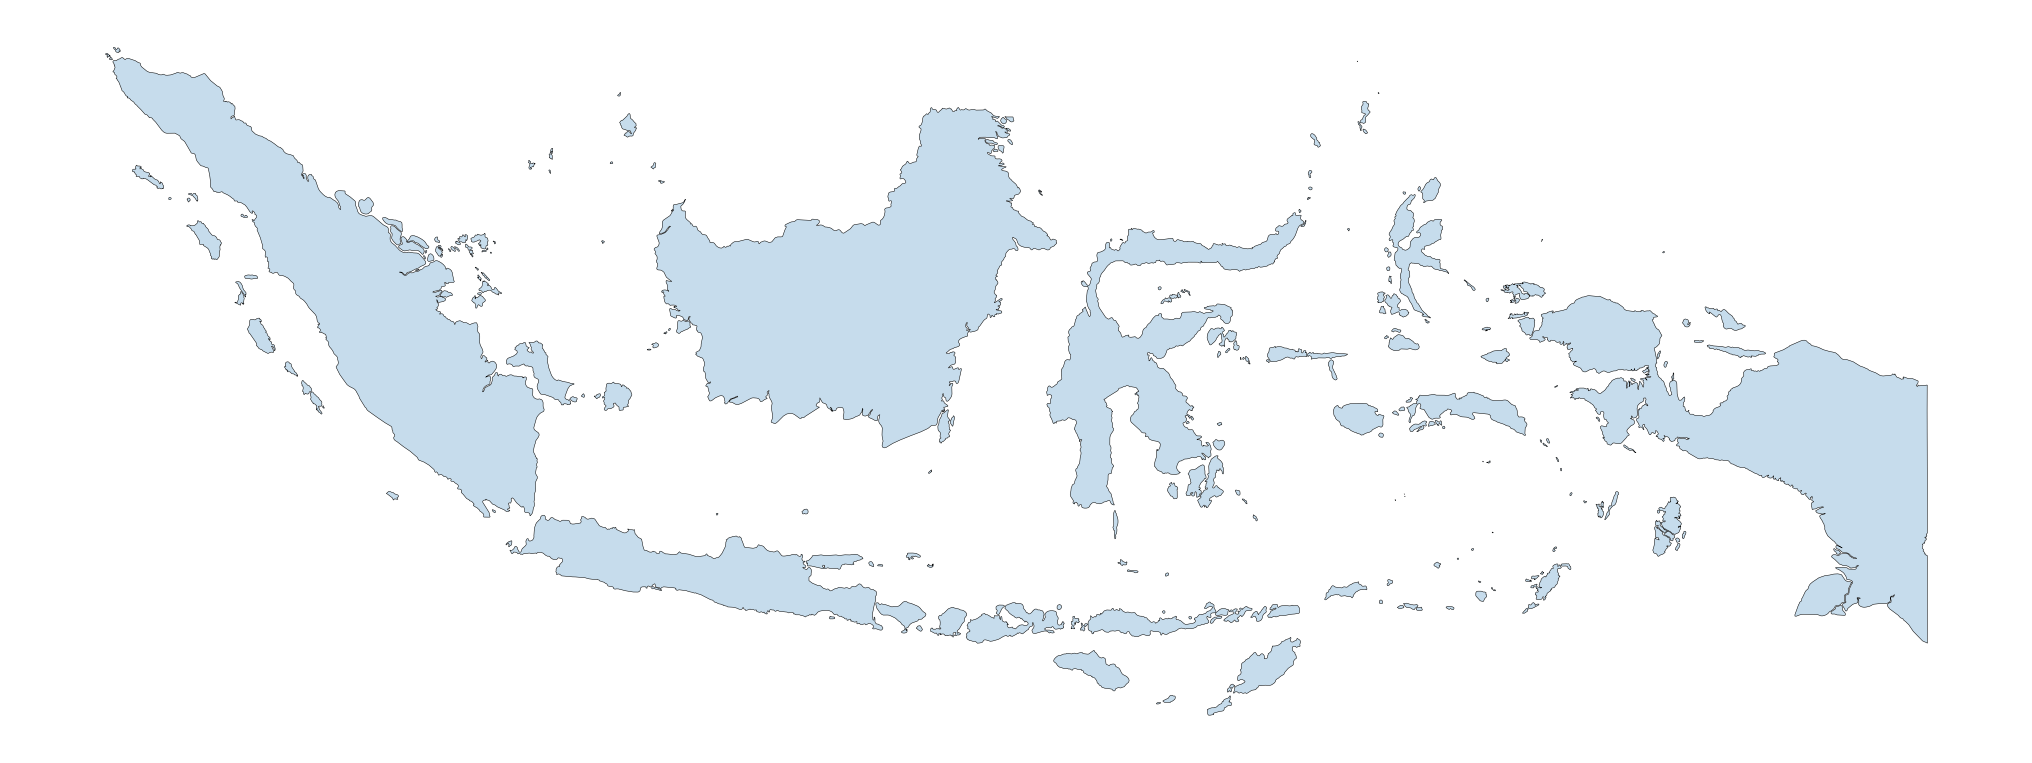

In [27]:
fig, ax = plt.subplots(figsize=(14, 9), dpi=144)
world.query('ISO_A3 in @region_list').plot(facecolor='tab:blue', alpha=0.25, ax=ax)
world.query('ISO_A3 in @region_list').plot(facecolor='none', edgecolor='k', lw=0.25, ax=ax)
# rivers.plot(edgecolor='dodgerblue', lw=0.5, ax=ax)
# region_point_grid.plot( markersize=0.1, 
#                                       ax=ax, )

ax.axis('off')
# plt.title("Synthetic vs. real data")
plt.show()

# Model on the SEA data set: HSGP component

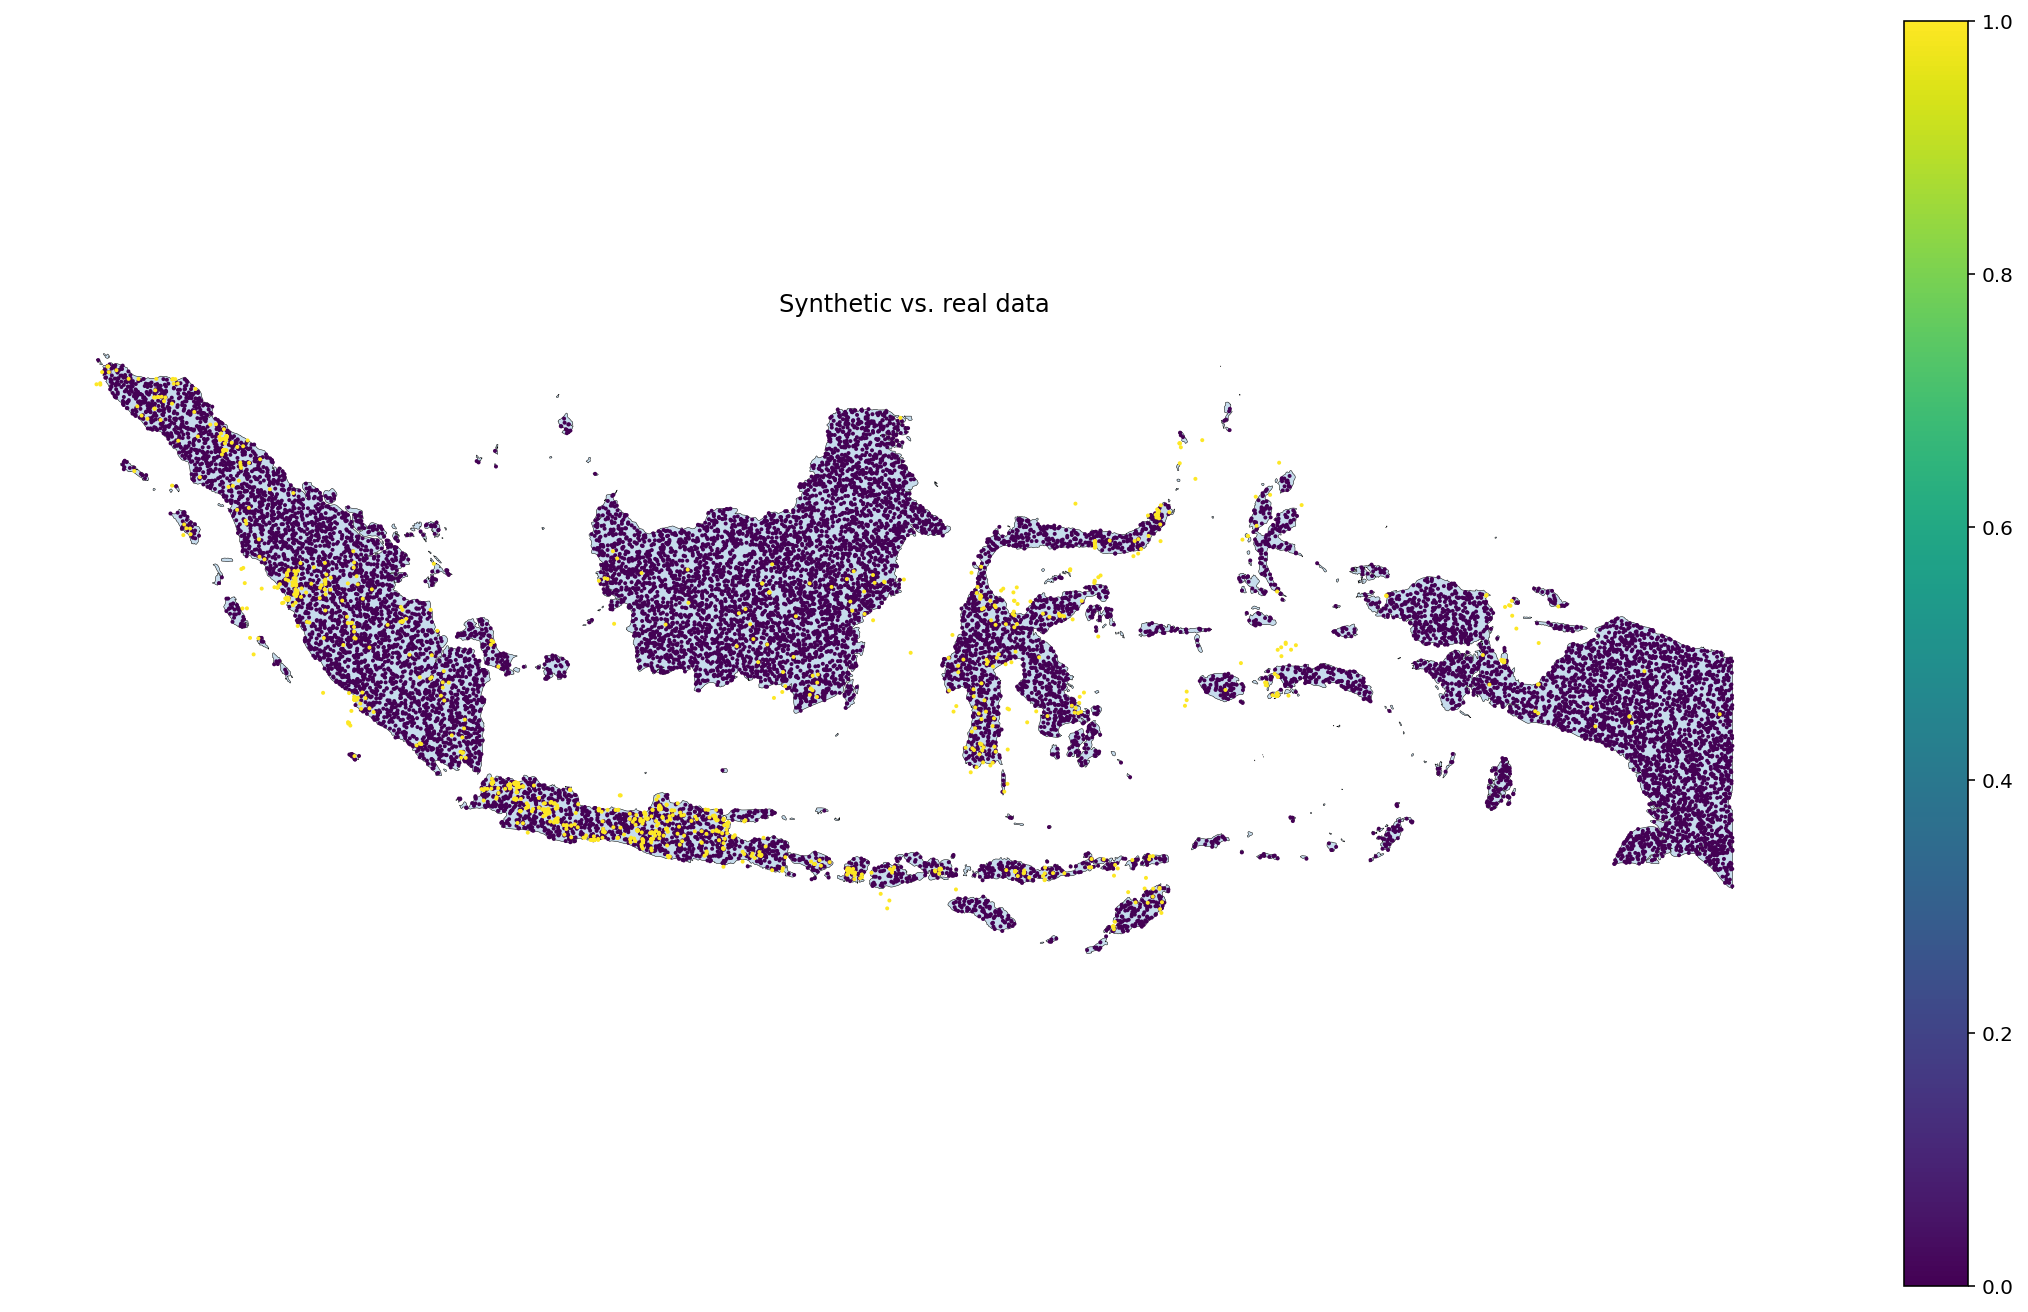

In [28]:
fig, ax = plt.subplots(figsize=(14, 9), dpi=144)
world.query('ISO_A3 in @region_list ').plot(facecolor='tab:blue', alpha=0.25, ax=ax)
world.query('ISO_A3 in @region_list').plot(facecolor='none', edgecolor='k', lw=0.25, ax=ax)
# rivers.plot(edgecolor='dodgerblue', lw=0.5, ax=ax)

region_df.plot('is_disaster', 
                                      markersize=1, 
                                      ax=ax, 
                                      legend=True, 
                                      # categorical=True,
                                      cmap='viridis')
ax.axis('off')
plt.title("Synthetic vs. real data")
plt.show()

In [29]:
#Define cooords
is_disaster_idx , is_disaster = pd.factorize(region_df["is_disaster"])
ISO_idx, ISO = pd.factorize(region_df["ISO"]) 
obs_idx = region_df.index
gp_features = ["lat", "long"]

#Creating idx
xr_idx = xr.Coordinates.from_pandas_multiindex(region_df.set_index(['ISO', 'Start_Year']).index, 'obs_idx')

#Set coords
coords_sea = {"is_disaster" : is_disaster,
        "obs_idx": obs_idx,
        "ISO": ISO,
        "feature": features_stand,
        "gp_feature":gp_features }

# Model on the SEA data set: Full model

In [30]:
region_df_stand.shape

(16841, 32)

In [31]:
with pm.Model(coords=coords_sea) as model_sea_full:
    #Declare data
    X, Y= add_data(features= features_stand ,  target = "is_disaster", df =  region_df_stand, )
    ISO_idx_pt = pm.Data("ISO_idx_pt", ISO_idx, dims= ["obs_idx"] )
    
    # # #Country effect
    country_effect = pm.Normal("country_effect", mu = 0, sigma =1, dims = ["ISO"])

    # #Betas
    beta_sigma = [0.1] * 8
    beta = pm.Normal("beta", mu = 0, sigma = beta_sigma, dims = ["feature"])

    # HSGP process
    X_gp = pm.Data("X_gp", region_df[["lat", "long"]])

    # Prior on the HSGP
    eta = pm.Exponential("eta", scale=2)
    ell_params = pm.find_constrained_prior(
        pm.Lognormal, lower=0.5, upper=10.0, mass=0.95, init_guess={"mu": 1.0, "sigma": 1.0}
    )
    ell = pm.Lognormal("ell", **ell_params, dims=["gp_feature"])
    cov_func = eta**2 * pm.gp.cov.Matern52(input_dim=2, ls=ell)

    m0, m1, c = 35, 35, 1.5
    gp = pm.gp.HSGP(m=[m0, m1], c=c, cov_func=cov_func)

    phi, sqrt_psd = gp.prior_linearized(X=X_gp)

    basis_coeffs = pm.Normal("basis_coeffs", size=gp.n_basis_vectors)
    HSGP_component = pm.Deterministic("HSGP_component", phi @ (basis_coeffs * sqrt_psd),dims= ["obs_idx"])


    #Model mu
    mu = pm.Deterministic("mu", 
                          country_effect[ISO_idx_pt] + 
                          X@beta +
                          HSGP_component , dims= ["obs_idx"] )
    

    # Now define the observed variable separately
    y_hat = pm.Bernoulli('y_hat', logit_p=mu, observed=Y, dims=['obs_idx'])

C:\Users\camil\AppData\Local\Temp\ipykernel_63416\1792770036.py:18: FutureWarning: find_constrained_prior is deprecated and will be removed in a future version. Please use maxent function from PreliZ. https://preliz.readthedocs.io/en/latest/api_reference.html#preliz.unidimensional.maxent
  ell_params = pm.find_constrained_prior(


#Set the prior predictions
with freeze_dims_and_data(model_sea_full):
   prior_idata = pm.sample_prior_predictive( compile_kwargs = {"mode":"JAX"})

prior_idata.prior_predictive["y_hat"] = prior_idata.prior_predictive["y_hat"].astype(int)

az.plot_ppc(prior_idata, group = "prior", observed = prior_idata.observed_data  );

In [32]:
if exists("idn_0.idata"):
    asean_idata = az.from_netcdf("idn_0.idata")

else:
    compiled_model = nutpie.compile_pymc_model(freeze_dims_and_data(model_sea_full), backend="jax", gradient_backend='jax')
    asean_idata = nutpie.sample(compiled_model, chains = 6, draws = 600, target_accept = 0.9)
    # Save the idata
    az.to_netcdf(data=asean_idata, filename=pathlib.Path("idn_0.idata"))


Progress,Draws,Divergences,Step Size,Gradients/Draw
,1000,0,0.06,127
,1000,0,0.07,127
,1000,0,0.06,127
,1000,0,0.06,127
,1000,0,0.06,127
,1000,0,0.06,127


### SEA predictions

In [33]:
az.summary(asean_idata, var_names=["beta", "eta", "eta_log__", "country_effect"] )

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta[log_distance_to_river__standardized],0.017,0.059,-0.090,0.131,0.001,0.001,8825.0,2794.0,1.00
beta[log_distance_to_coastline__standardized],0.024,0.054,-0.072,0.127,0.001,0.001,5728.0,2552.0,1.00
beta[Population__standardized],0.243,0.086,0.092,0.405,0.001,0.002,9177.0,2748.0,1.00
beta[co2__standardized],0.210,0.083,0.058,0.377,0.001,0.002,8025.0,2466.0,1.00
beta[precip_deviation__standardized],0.033,0.036,-0.033,0.100,0.000,0.001,5076.0,3108.0,1.00
beta[dev_ocean_temp__standardized],0.058,0.037,-0.015,0.125,0.001,0.001,4710.0,2335.0,1.00
beta[log_population_density__standardized],0.178,0.085,0.015,0.341,0.001,0.002,9564.0,2571.0,1.00
beta[log_gdp_per_cap__standardized],0.033,0.082,-0.133,0.178,0.001,0.002,8052.0,2753.0,1.01
eta,3.511,0.393,2.871,4.285,0.015,0.015,739.0,781.0,1.01
eta_log__,1.250,0.108,1.056,1.456,0.004,0.003,739.0,781.0,1.01


In [34]:
# full model SEA predictions

# Rebuild ISO_idx_sea
ISO_to_idx = {name: idx for idx, name in enumerate(ISO)}
ISO_idx_sea=  region_point_grid_extended['2020'].ISO.map(ISO_to_idx.get)

asean_idata_plot = {}

for year in ["2020",]:
    with model_sea_full.copy() as temp_model:
        #Declare data
        pm.set_data({"X_gp":region_point_grid_extended[year][["lat", "long"]],
                     "Y": np.full(region_point_grid_extended[year].shape[0], 0 ),
                     "X": region_point_grid_extended[year][features_stand],
                     "ISO_idx_pt": ISO_idx_sea
     
                },
            coords= {"obs_idx": region_point_grid_extended[year].index.values } 
           )
    
        y_hat_invlogit = pm.Deterministic('y_hat_invlogit', pm.math.invlogit(temp_model["y_hat"] ))

        HSGP_component_invlogit = pm.Deterministic('HSGP_component_invlogit', pm.math.invlogit(temp_model["HSGP_component"] ))
    
    
    
    with freeze_dims_and_data(temp_model):
        asean_idata_plot[year] = pm.sample_posterior_predictive(asean_idata, var_names=["y_hat_invlogit","y_hat", "HSGP_component",
                                                                                                          "HSGP_component_invlogit",], 
                                                             )


Sampling: [y_hat]


Output()

In [35]:
# Create the geopandas version of the predictions
model_sea_full_predictions_geo = {}

for year in ["2020",]:
    model_sea_full_predictions_geo[year] = prediction_to_gpd_df(prediction_idata = asean_idata_plot[year] , 
                         variables = ["y_hat_invlogit", "y_hat" ,"HSGP_component","HSGP_component_invlogit"  ] , 
                         points = region_point_grid_extended['2020'] )

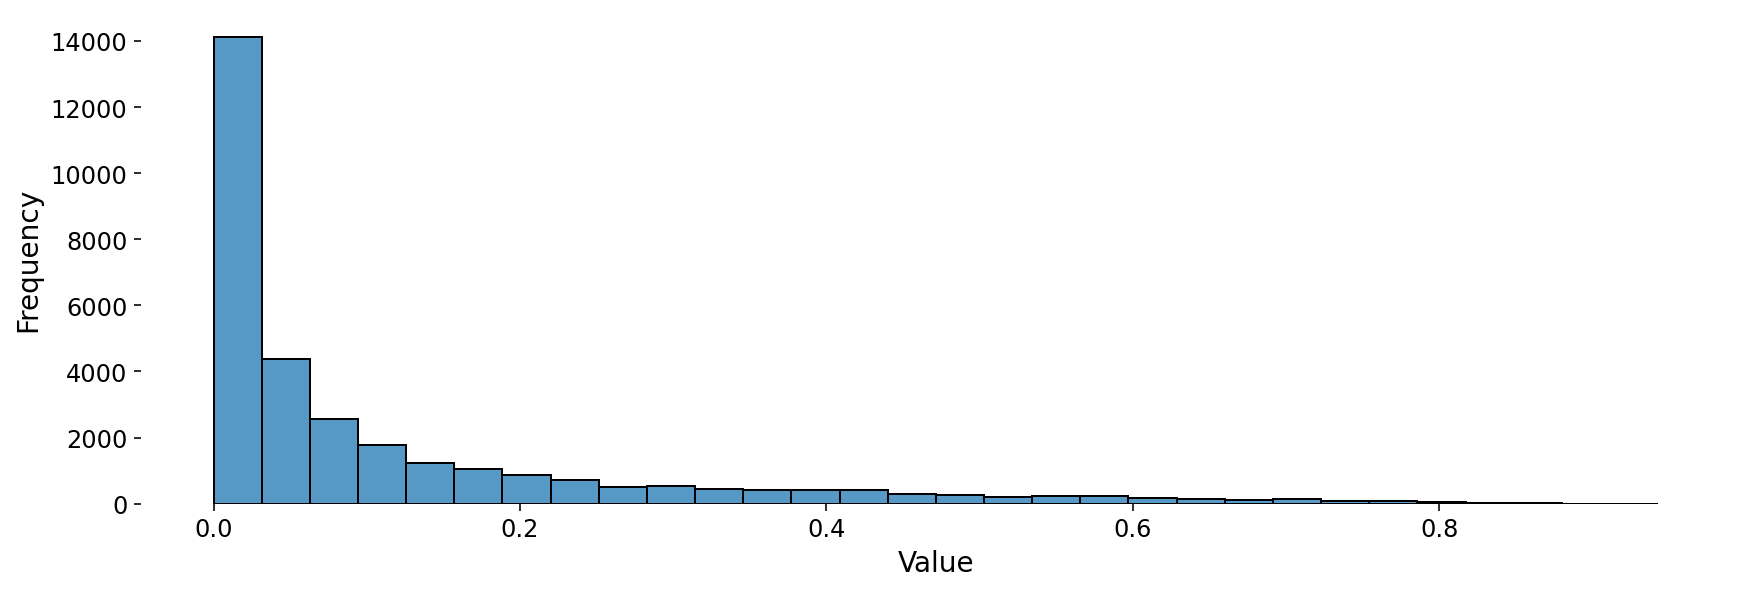

In [36]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(12, 4), dpi= 144 )

sns.histplot( data = model_sea_full_predictions_geo["2020"]["y_hat"]["y_hat"], bins = 30
             , ax = ax,  )
ax.set_xlabel("Value", fontsize=14)  # X-axis label
ax.set_ylabel("Frequency", fontsize=14)  # Y-axis label
ax.tick_params(axis='both', which='major', labelsize=12)  # Tick labels
# fig.savefig(here("notebooks/final_paper/figures/event_full_neigh_hist.png"));

[]

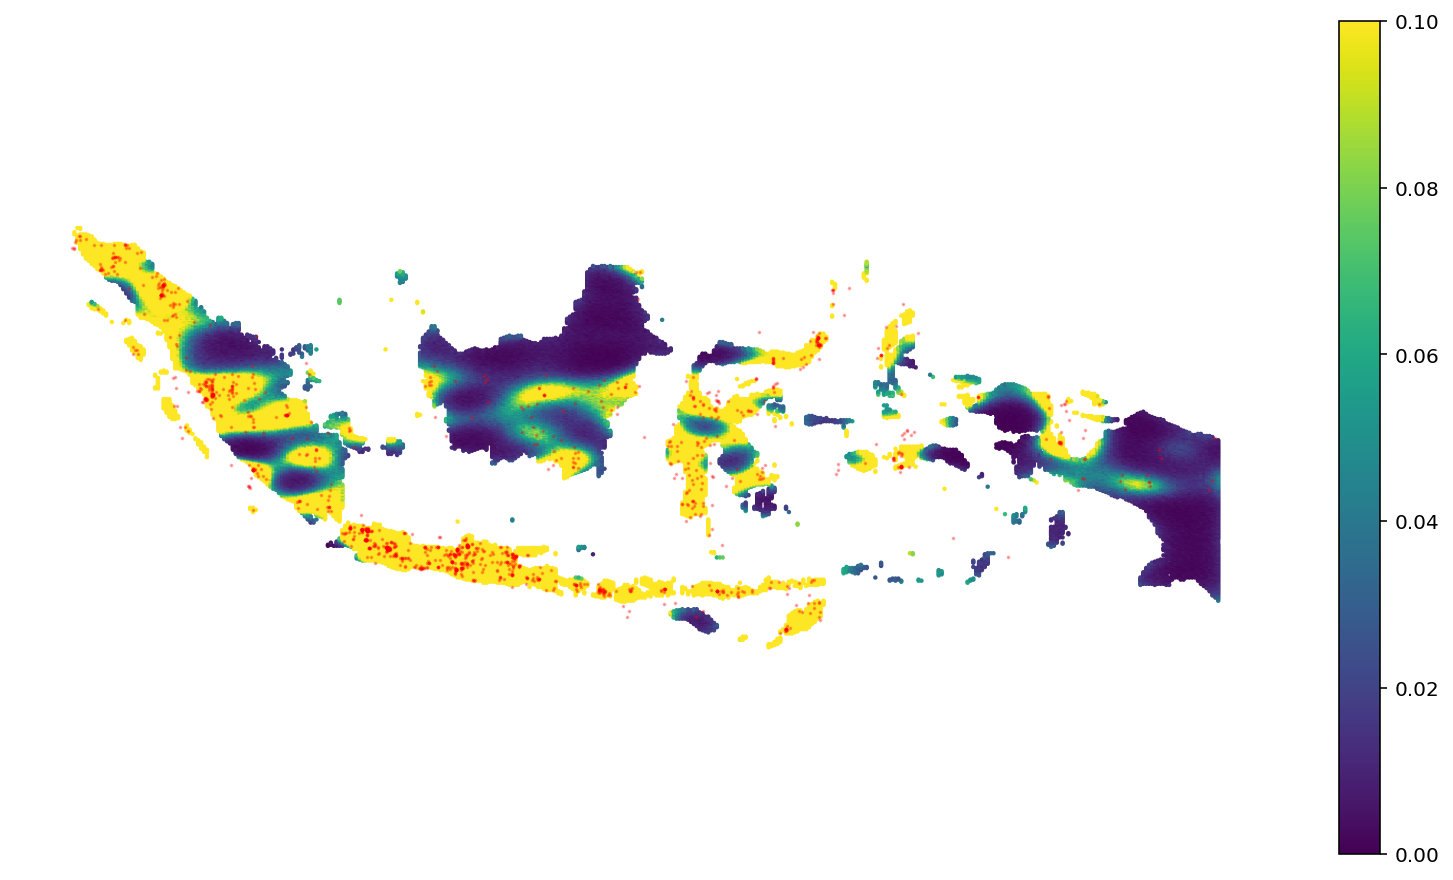

In [37]:
#Plot the predictions
fig, ax = plt.subplots(figsize=(10, 6), dpi= 144 )
model_sea_full_predictions_geo["2020"]["y_hat"].plot("y_hat",legend=True, ax=ax,markersize =1.5, vmax = 0.1 )
region_disasters_geo.plot(ax=ax, alpha = 0.3, c = "r", markersize =0.7, )
# plt.title("Event probability for Laos neighbors", );


ax.set_xticks([])
ax.set_yticks([])
# fig.savefig(here("notebooks/final_paper/figures/event_full_neigh_pred.png"));

In [38]:
# full model SEA predictions

# Rebuild ISO_idx_sea
ISO_to_idx = {name: idx for idx, name in enumerate(ISO)}
ISO_idx_laos =  region_point_grid_extended['2020'].ISO.map(ISO_to_idx.get)
asean_idata_plot_laos = {}

for year in ["2020", "2016"]:
    with model_sea_full.copy() as temp_model:
        #Declare data
        pm.set_data({"X_gp": region_point_grid[["lat", "long"]],
                     "Y": np.full(region_point_grid_extended['2020'].shape[0], 0 ),
                     "X": region_point_grid_extended[year][features_stand],
                     "ISO_idx_pt": ISO_idx_laos
     
                },
            coords= {"obs_idx": region_point_grid_extended['2020'].index.values } 
           )
    
        y_hat_invlogit = pm.Deterministic('y_hat_invlogit', pm.math.invlogit(temp_model["y_hat"] ))

        # River effect
        river_effect = pm.Deterministic('river_effect', temp_model["beta"][0] * region_point_grid_extended[year]['log_distance_to_river__standardized'])
        # Coast effect
        coast_effect = pm.Deterministic('coast_effect',  temp_model["beta"][1] * region_point_grid_extended[year]['log_distance_to_coastline__standardized'])
                                                
    
    with freeze_dims_and_data(temp_model):
        asean_idata_plot_laos[year] = pm.sample_posterior_predictive(
            asean_idata, var_names=["y_hat_invlogit","HSGP_component", "y_hat", "river_effect", "coast_effect"], 
                                                         )


Sampling: [y_hat]


Output()

Sampling: [y_hat]


Output()

In [39]:
# Create the geopandas version of the predictions
model_full_predictions_geo = {}

for year in ["2020", "2016"]:
    model_full_predictions_geo[year] = prediction_to_gpd_df(prediction_idata = asean_idata_plot_laos[year] , 
                         variables = ["y_hat_invlogit","HSGP_component", "y_hat", "river_effect",'coast_effect'] , 
                         points = region_point_grid_extended['2020'] )

<Axes: >

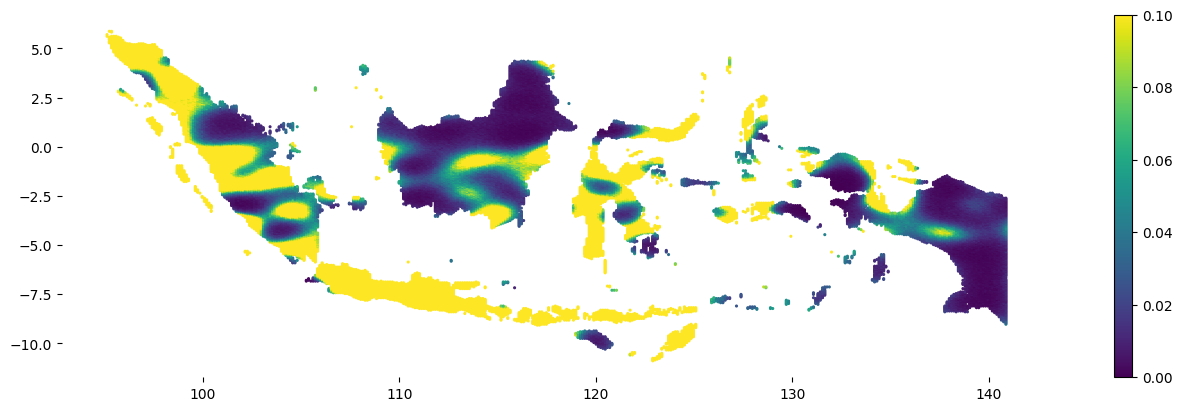

In [40]:
model_full_predictions_geo["2020"]["y_hat"].plot("y_hat", markersize=1.5, vmax=0.1, legend=True)

C:\Users\camil\AppData\Local\Temp\ipykernel_63416\4270594155.py:23: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(top=0.9, bottom=0.1, left=0.1, right=0.9, hspace=0.2, wspace=0.2)


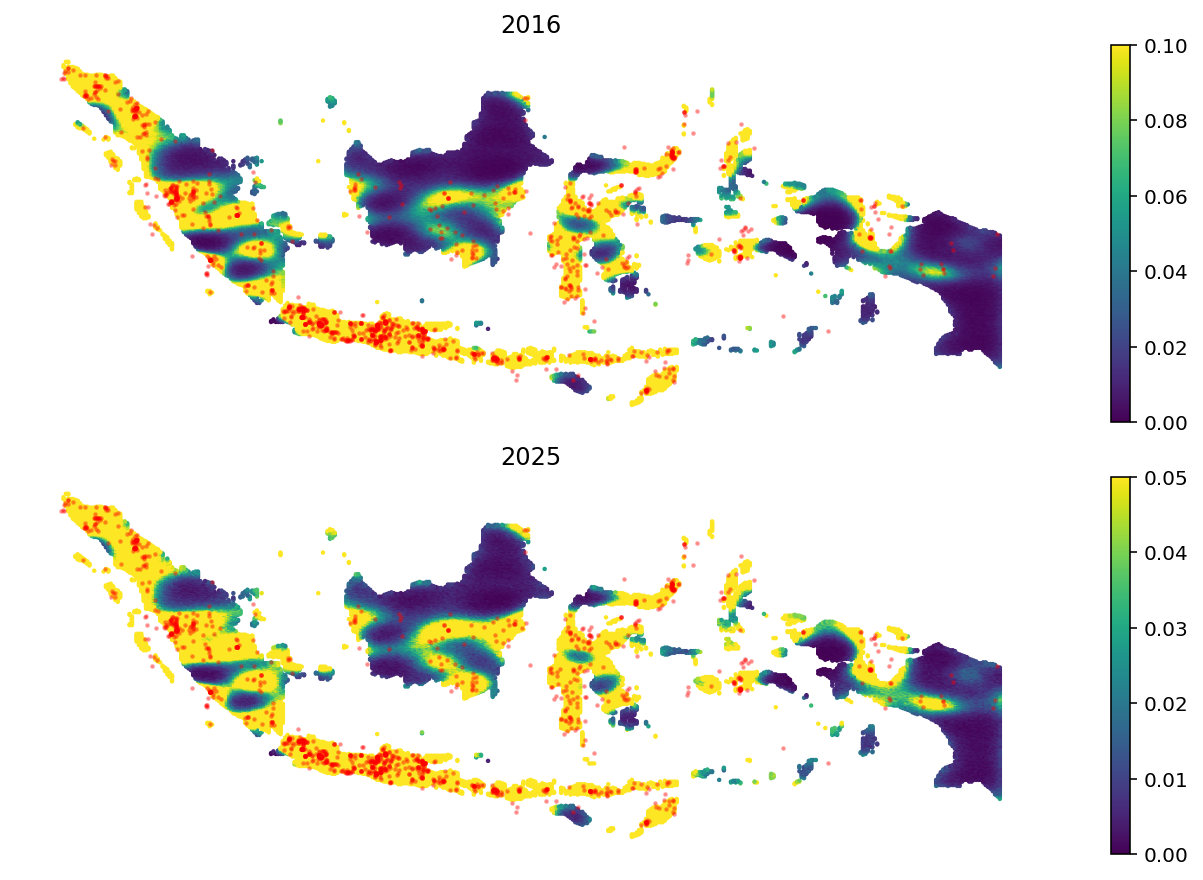

In [41]:
import matplotlib.pyplot as plt

# time change
fig, axes = plt.subplots(2, 1, figsize=(10, 6), dpi=144)



model_full_predictions_geo["2020"]["y_hat"].plot("y_hat", ax=axes[0], markersize=1.5, vmax=0.1, legend=True)
region_disasters_geo.plot(ax=axes[0], alpha=0.3, c="r", markersize=2)

model_full_predictions_geo["2016"]["y_hat"].plot("y_hat", legend=True, ax=axes[1], markersize=1.5, vmax=0.05)
region_disasters_geo.plot(ax=axes[1], alpha=0.3, c="r", markersize=2)

# Set ticks and titles for each subplot
for year, n in zip([2016, 2025], [0, 1]):
    axes[n].set_xticks([])
    axes[n].set_yticks([])
    axes[n].set_title(str(year))

# plt.suptitle('')

# Adjust the spacing around the subplots
plt.subplots_adjust(top=0.9, bottom=0.1, left=0.1, right=0.9, hspace=0.2, wspace=0.2)

# Uncomment the following line to save the figure
# fig.savefig(here("notebooks/final_paper/data/figures/laos_pred_time_change.png"))
